# Thai Receipt Validation Notebook
OCR field detection + ML classification for Thai receipts (~560 augmented images)

In [1]:
import os, re, time, json, pickle, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['font.family'] = ['DejaVu Sans']
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)
from openai import OpenAI, RateLimitError
print('Imports done')


Imports done


In [2]:
API_KEY = os.environ.get('TYPHOON_API_KEY', '')
if not API_KEY:
    raise ValueError('Please set the TYPHOON_API_KEY environment variable')
print('API key loaded')


API key loaded


In [3]:
from openai import OpenAI, RateLimitError

client = OpenAI(
    api_key=API_KEY,
    base_url='https://api.opentyphoon.ai/v1'
)

def extract_text(image_path):
    """Send image to Typhoon OCR and return extracted text."""
    with open(image_path, 'rb') as f:
        image_data = base64.b64encode(f.read()).decode('utf-8')
    ext = image_path.split('.')[-1].lower()
    mime = 'image/jpeg' if ext in ['jpg', 'jpeg'] else 'image/png'
    for attempt in range(5):
        try:
            response = client.chat.completions.create(
                model='typhoon-ocr',
                messages=[{
                    'role': 'user',
                    'content': [
                        {'type': 'image_url', 'image_url': {'url': f'data:{mime};base64,{image_data}'}},
                        {'type': 'text', 'text': 'Extract all text from this receipt image.'}
                    ]
                }],
                max_tokens=2000
            )
            return response.choices[0].message.content
        except RateLimitError:
            wait = 60 * (attempt + 1)
            print(f'Rate limit, waiting {wait}s... (attempt {attempt+1}/5)')
            time.sleep(wait)
        except Exception as e:
            print(f'Error: {e}')
            time.sleep(10)
    return ''

print('extract_text() ready')


extract_text() ready


In [ ]:
FIELDS = [
    'has_store_name',     # ชื่อร้าน/บริษัท
    'has_store_address',  # ที่อยู่ร้าน
    'has_store_tax_id',   # เลขประจำตัวผู้เสียภาษีร้าน
    'has_date',           # วันที่
    'has_amount',         # ยอดรวม (ตัวเลข)
    'has_amount_words',   # จำนวนเงินเป็นตัวอักษร
    'has_signature',      # ลายเซ็น/ผู้รับรอง
    'has_mfu_name',       # ชื่อมหาวิทยาลัยแม่ฟ้าหลวง
    'has_mfu_address',    # ที่อยู่ MFU
    'has_mfu_tax_id',     # เลขประจำตัวผู้เสียภาษีของ MFU
]

THAI_MONTHS = (
    'มกราคม|ม\.ค\.|กุมภาพันธ์|ก\.พ\.|มีนาคม|มี\.ค\.|เมษายน|เม\.ย\.|'
    'พฤษภาคม|พ\.ค\.|มิถุนายน|มิ\.ย\.|กรกฎาคม|ก\.ค\.|'
    'สิงหาคม|ส\.ค\.|กันยายน|ก\.ย\.|ตุลาคม|ต\.ค\.|'
    'พฤศจิกายน|พ\.ย\.|ธันวาคม|ธ\.ค\.'
)
ENG_MONTHS = (
    'jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec|'
    'january|february|march|april|june|july|august|september|october|november|december'
)

def normalize(text):
    return re.sub(r'\s+', ' ', text.lower().strip())

print('FIELDS and helpers defined:', len(FIELDS), 'fields')


FIELDS and helpers defined: 10 fields


In [5]:
# NOTE: Detection functions (Thai-aware) are defined in the next cell.


In [6]:
# ── Detection Functions (Thai-aware) ────────────────────────────────

def detect_store_name(text):
    """ชื่อร้าน/บริษัท: Thai company suffixes + English business keywords."""
    t = normalize(text)
    thai = ['จำกัด','มหาชน','บริษัท','ห้างหุ้นส่วน','ร้าน','หจก.','บจก.','บมจ.']
    eng  = ['co.,ltd','co., ltd','ltd.','company','shop','store','bakery',
            'cafe','restaurant','hotel','hospital','clinic','center','centre',
            'service','technology','university','inc.','inc,']
    return int(any(kw in t for kw in thai + eng))


def detect_store_address(text):
    """ที่อยู่ร้าน: Thai address patterns."""
    thai_addr = ['หมู่','ตำบล','ต.','อำเภอ','อ.','จังหวัด','จ.',
                 'ถนน','ถ.','ซอย','ซ.','แขวง','เขต',
                 'กรุงเทพ','กรุงเทพมหานคร','นนทบุรี','ปทุมธานี',
                 'เชียงราย','เชียงใหม่','ขอนแก่น','โทร','โทรศัพท์']
    eng_addr  = ['road','rd.','street','st.','anywhere st','moo','any city']
    lines = text.split('\n')
    for line in lines:
        l = line.strip()
        if not l or len(l) < 4: continue
        if any(kw in l for kw in thai_addr): return 1
        if any(kw in l.lower() for kw in eng_addr): return 1
        if re.search(r'^\d+[\/]\d+', l): return 1
        if re.search(r'\b1\d{4}\b|\b[2-9]\d{4}\b', l): return 1
    return 0


def detect_store_tax_id(text):
    """เลขประจำตัวผู้เสียภาษีร้าน: 13-digit Thai tax ID (not MFU's)."""
    MFU_TAX_ID = '0994000163481'
    thai_labels = ['เลขประจำตัวผู้เสียภาษี','เลขผู้เสียภาษี',
                   'เลขประจำตัวนิติบุคคล','tax id','tax no']
    t_lower = text.lower()
    for label in thai_labels:
        if label in text or label in t_lower:
            idx = text.find(label) if label in text else t_lower.find(label)
            nums = re.findall(r'\d{10,13}', text[idx:idx+40])
            for n in nums:
                if n != MFU_TAX_ID: return 1
    all_ids = re.findall(r'\b\d{13}\b', text)
    for tid in all_ids:
        if tid != MFU_TAX_ID: return 1
    return 0


def detect_date(text):
    """วันที่: Thai Buddhist Era dates, Thai month names, DD/MM/YY formats."""
    if re.search(r'วันที่\s*\d', text): return 1
    if re.search(THAI_MONTHS, text): return 1
    if re.search(r'\b\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}\b', text): return 1
    if re.search(r'(date|วัน)[:\s]+.{1,20}\d{2,4}', text, re.IGNORECASE): return 1
    if re.search(r'\b\d{1,2}\s+(' + ENG_MONTHS + r')\s+\d{4}\b', text, re.IGNORECASE): return 1
    return 0


def detect_amount(text):
    """ยอดรวม: total amount as a number."""
    thai_total = ['ยอดรวมทั้งหมด','จำนวนเงินรวมทั้งสิ้น','รวมทั้งสิ้น',
                  'ยอดรวม','รวมเป็นเงิน','ราคารวมสุทธิ','ยอดชำระ',
                  'รวมสุทธิ','จำนวนเงินทั้งสิ้น','รวมทั้งหมด']
    for kw in thai_total:
        if kw in text:
            idx = text.find(kw)
            if re.search(r'[฿]?[\d,]{3,}', text[idx:idx+60]): return 1
    if re.search(r'(grand\s*total|total\s*amount)[\s:]*[฿$]?[\d,]+\.?\d*',
                 text, re.IGNORECASE): return 1
    return 0


def detect_amount_in_words(text):
    """จำนวนเงินเป็นตัวอักษร: amount spelled out in Thai words."""
    t = normalize(text)
    if 'บาทถ้วน' in text or 'บาทถ้วน' in t: return 1
    thai_num_words = ['หนึ่ง','สอง','สาม','สี่','ห้า','หก',
                      'เจ็ด','แปด','เก้า','สิบ','ร้อย','พัน',
                      'หมื่น','แสน','ล้าน']
    if any(w in text for w in thai_num_words) and 'บาท' in text:
        for w in thai_num_words:
            if w in text:
                idx = text.find(w)
                if 'บาท' in text[idx:idx+60]: return 1
    if re.search(r'baht\s+only', t): return 1
    if re.search(r'\(?[a-z\s\-,]+baht', t): return 1
    return 0


def detect_signature(text):
    """ลายเซ็น: signature or authorisation field."""
    t = normalize(text)
    thai_sig = ['ผู้รับเงิน','ผู้จ่ายเงิน','ผู้อนุมัติ','ผู้ตรวจสอบ',
                'ผู้จัดการ','ผู้รับใบแจ้งหนี้','ผู้ออกใบแจ้งหนี้',
                'ผู้รับบิล','ผู้วางบิล','เจ้าหน้าที่การเงิน',
                'ผู้รับสินค้า','ผู้จัดทำ','ผู้ส่งสินค้า','ผู้อุมัติ',
                'cashier','signature','signed by','approved by',
                'received by','authorised by','delivery by']
    return int(any(kw in t for kw in thai_sig))


def detect_mfu_name(text):
    """ชื่อมหาวิทยาลัยแม่ฟ้าหลวง."""
    t = normalize(text)
    mfu_keywords = ['มหาวิทยาลัยแม่ฟ้าหลวง','แม่ฟ้าหลวง',
                    'mae fah luang','mfu','มฟล','mae fah luang university']
    return int(any(kw in t for kw in mfu_keywords))


def detect_mfu_address(text):
    """ที่อยู่ MFU."""
    t = normalize(text)
    mfu_addr_keywords = ['333','หมู่ที่ 1','ม.1','ตำบลท่าสุด','ท่าสุด',
                         'อำเภอเมืองเชียงราย','เมืองเชียงราย',
                         'เชียงราย 57100','57100','mfu road','nang lae']
    return int(any(kw in t for kw in mfu_addr_keywords))


def detect_mfu_tax_id(text):
    """เลขประจำตัวผู้เสียภาษีของ MFU: 0994000163481."""
    if '0994000163481' in text: return 1
    t = normalize(text)
    if any(kw in t for kw in ['มฟล','แม่ฟ้าหลวง','mfu']):
        if re.search(r'\b\d{13}\b', text): return 1
    return 0


print('All 10 detection functions defined.')


All 10 detection functions defined.


In [7]:
gt = pd.read_csv('ground_truth_thai.csv')
print('Ground truth loaded:', gt.shape)
print('Label distribution:')
print(gt['label'].value_counts())
print()
print(gt.head(3).to_string())


Ground truth loaded: (632, 12)
Label distribution:
label
0    632
Name: count, dtype: int64

             filename  has_store_name  has_store_address  has_store_tax_id  has_date  has_amount  has_amount_words  has_signature  has_mfu_name  has_mfu_address  has_mfu_tax_id  label
0  10_rot45_ccw_0.jpg               0                  0                 0         0           0                 0              0             0                0               0      0
1  10_rot45_ccw_1.jpg               0                  0                 0         0           0                 0              0             0                0               0      0
2  10_rot45_ccw_2.jpg               0                  0                 0         0           0                 0              0             0                0               0      0


In [8]:
def build_dataset(folder, gt_df, resume=True):
    """
    Run Typhoon OCR on all augmented Thai receipt images and extract 10 fields.
    resume=True: skips images already saved in ocr_results_thai.csv
    Checkpoints every 10 images.
    """
    done = set()
    existing_rows = []
    if resume and os.path.exists('ocr_results_thai.csv'):
        existing_df = pd.read_csv('ocr_results_thai.csv')
        done = set(existing_df['filename'].tolist())
        existing_rows = existing_df.to_dict('records')
        print(f'Resuming: {len(done)} already done')

    rows = existing_rows.copy()
    images = sorted([f for f in os.listdir(folder)
                     if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    remaining = [img for img in images if img not in done]
    print(f'Total: {len(images)} | Remaining: {len(remaining)}')
    print(f'Estimated time: ~{len(remaining)*3/60:.0f} minutes\n')

    for idx, img in enumerate(remaining):
        path = os.path.join(folder, img)
        gt_row = gt_df[gt_df['filename'] == img]
        if gt_row.empty:
            print(f'[{idx+1}/{len(remaining)}] Skipping {img} - not in ground_truth')
            continue

        print(f'[{idx+1}/{len(remaining)}] {img}', end=' ')
        text = extract_text(path)
        if not text:
            print('FAILED'); continue

        label = int(gt_row.iloc[0]['label'])
        rows.append({
            'filename':          img,
            'has_store_name':    detect_store_name(text),
            'has_store_address': detect_store_address(text),
            'has_store_tax_id':  detect_store_tax_id(text),
            'has_date':          detect_date(text),
            'has_amount':        detect_amount(text),
            'has_amount_words':  detect_amount_in_words(text),
            'has_signature':     detect_signature(text),
            'has_mfu_name':      detect_mfu_name(text),
            'has_mfu_address':   detect_mfu_address(text),
            'has_mfu_tax_id':    detect_mfu_tax_id(text),
            'label':             label
        })
        print(f'-> label={label}')

        if (idx + 1) % 10 == 0:
            pd.DataFrame(rows).to_csv('ocr_results_thai.csv', index=False)
            print(f'  [Checkpoint saved: {idx+1} images]')
        time.sleep(1)

    return rows

# Change folder name to your Thai receipt images folder
raw_rows = build_dataset('augmented_thaireceipts', gt, resume=True)
df = pd.DataFrame(raw_rows)
df.to_csv('ocr_results_thai.csv', index=False)
print(f'\nocr_results_thai.csv saved! Total: {len(df)} rows')
print(df['label'].value_counts())


Resuming: 632 already done
Total: 632 | Remaining: 0
Estimated time: ~0 minutes


ocr_results_thai.csv saved! Total: 632 rows
label
1    400
0    232
Name: count, dtype: int64


⚠ Column has_mfu_name missing from ocr_results_thai.csv → filling with 0
⚠ Column has_mfu_address missing from ocr_results_thai.csv → filling with 0
⚠ Column has_mfu_tax_id missing from ocr_results_thai.csv → filling with 0
GT  columns : ['filename', 'has_store_name', 'has_store_address', 'has_store_tax_id', 'has_date', 'has_amount', 'has_amount_words', 'has_signature', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id', 'label']
OCR columns : ['filename', 'has_store_name', 'has_store_address', 'has_store_tax_id', 'has_date', 'has_amount', 'has_amount_words', 'has_signature', 'label', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id']

Merged: 632 rows
Merged columns: ['filename', 'has_store_name_gt', 'has_store_address_gt', 'has_store_tax_id_gt', 'has_date_gt', 'has_amount_gt', 'has_amount_words_gt', 'has_signature_gt', 'has_mfu_name_gt', 'has_mfu_address_gt', 'has_mfu_tax_id_gt', 'label_gt', 'has_store_name_ocr', 'has_store_address_ocr', 'has_store_tax_id_ocr', 'has_date_ocr', 'ha

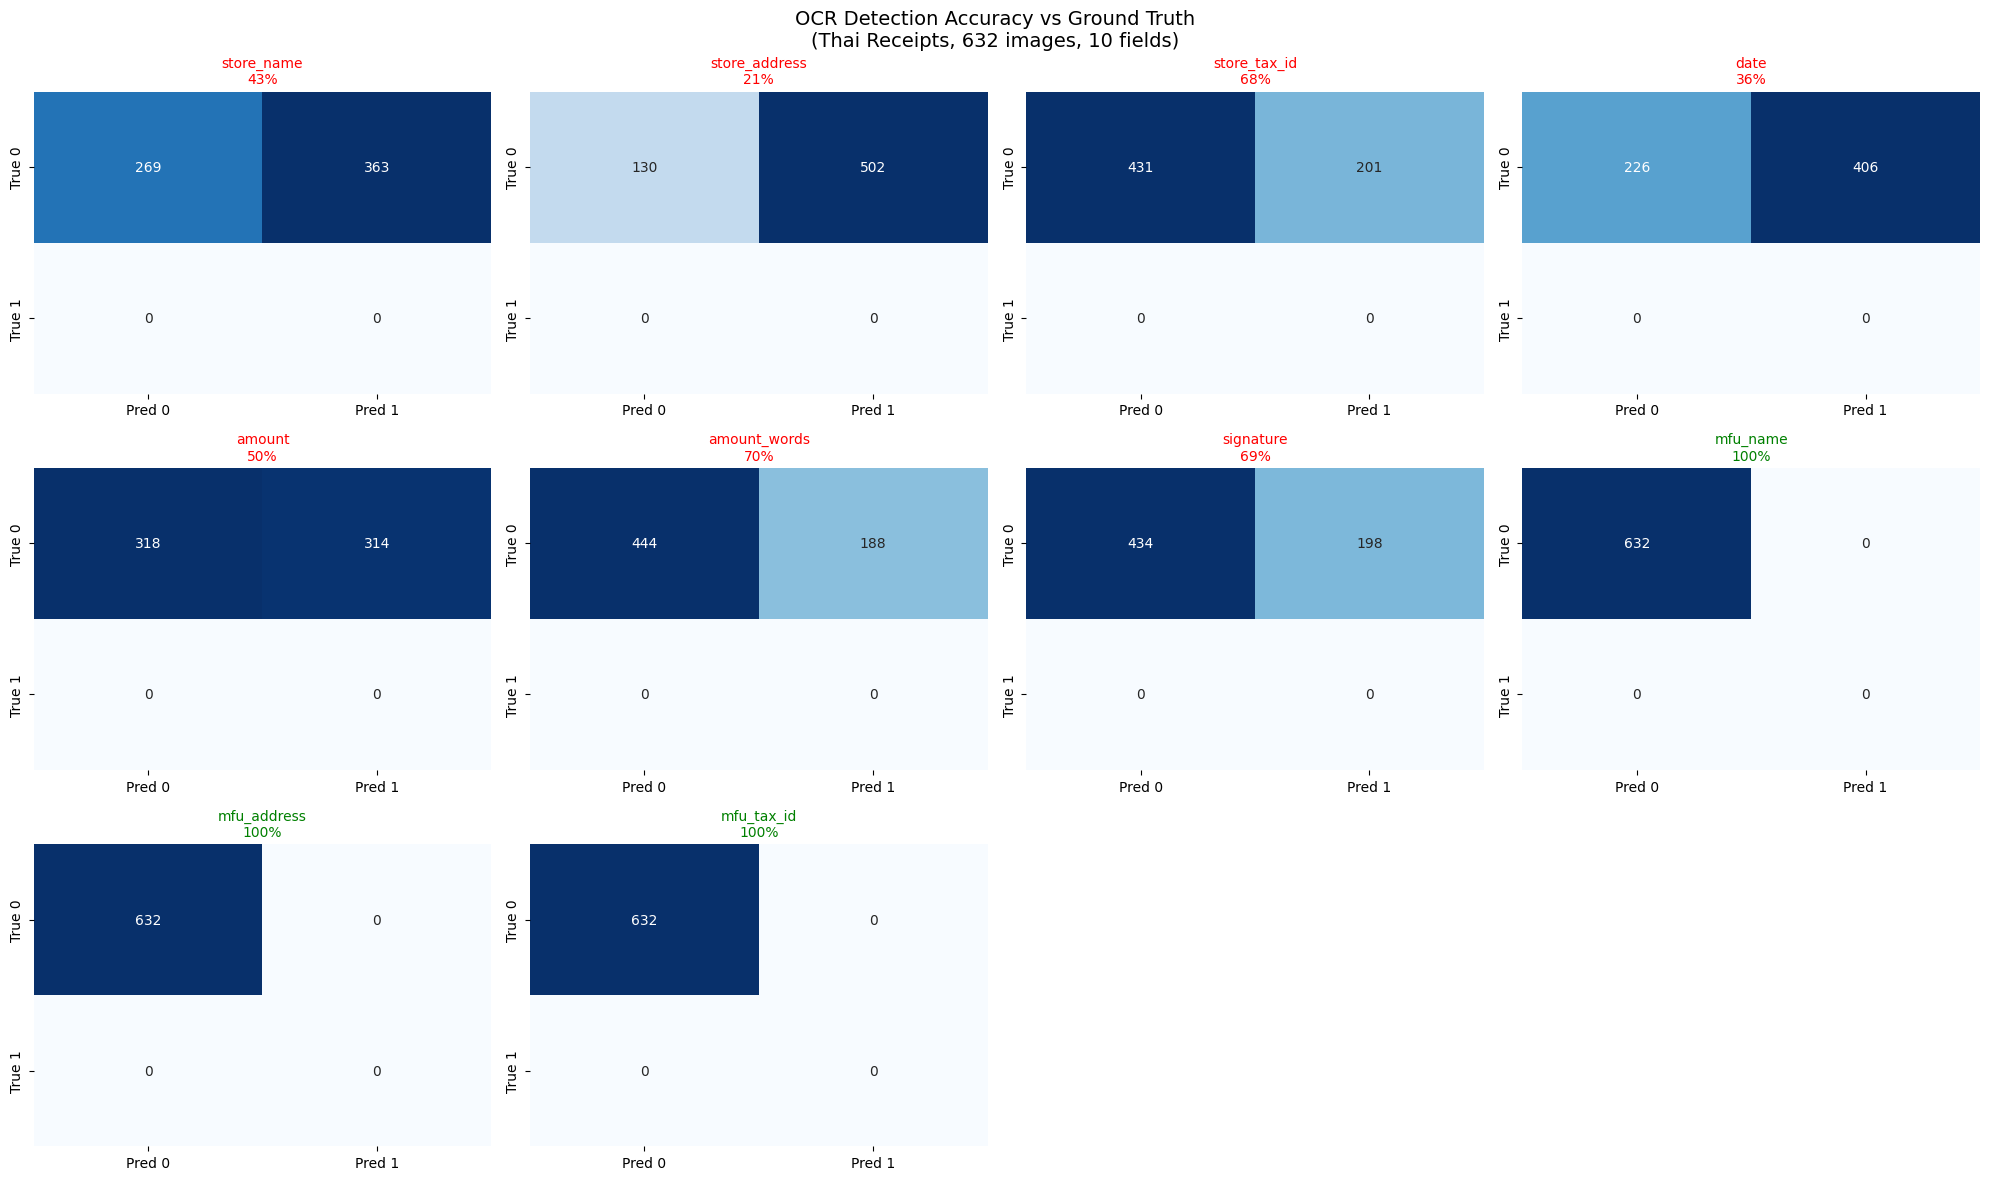

Saved --> field_accuracy_thai.png


In [11]:
gt_df  = pd.read_csv('ground_truth_thai.csv')
ocr_df = pd.read_csv('ocr_results_thai.csv')

# ── Fix: rename old field names to match current FIELDS if needed ─────
rename_map = {
    'has_store_phone':    None,   # drop - not in FIELDS
    'has_invoice_number': None,   # drop - not in FIELDS
    'has_item_list':      None,   # drop - not in FIELDS
    'has_vat':            None,   # drop - not in FIELDS
}
drop_cols = [c for c, v in rename_map.items() if v is None and c in ocr_df.columns]
ocr_df = ocr_df.drop(columns=drop_cols)

# ── Add missing MFU columns as 0 if not present ───────────────────────
for col in FIELDS:
    if col not in ocr_df.columns:
        print(f'⚠ Column {col} missing from ocr_results_thai.csv → filling with 0')
        ocr_df[col] = 0

# ── Clean and cast ────────────────────────────────────────────────────
for col in FIELDS:
    ocr_df[col] = pd.to_numeric(ocr_df[col], errors='coerce').fillna(0).astype(int)
for col in FIELDS:
    if col in gt_df.columns:
        gt_df[col] = pd.to_numeric(gt_df[col], errors='coerce').fillna(0).astype(int)

print('GT  columns :', gt_df.columns.tolist())
print('OCR columns :', ocr_df.columns.tolist())

merged = pd.merge(gt_df, ocr_df, on='filename', suffixes=('_gt', '_ocr'))
print(f'\nMerged: {len(merged)} rows')
print('Merged columns:', merged.columns.tolist())

# ── Only keep FIELDS that actually survived the merge ─────────────────
FIELDS_AVAILABLE = [
    f for f in FIELDS
    if (f + '_gt') in merged.columns and (f + '_ocr') in merged.columns
]
missing = [f for f in FIELDS if f not in FIELDS_AVAILABLE]
if missing:
    print(f'\n⚠ Fields missing from merged result (skipped): {missing}')
print(f'Fields used for comparison: {FIELDS_AVAILABLE}\n')

short_names = [f.replace('has_', '') for f in FIELDS_AVAILABLE]
col_w = 10
header_width = 28 + 14 + col_w * len(FIELDS_AVAILABLE)
print('Per-Image Comparison: Ground Truth vs OCR (first 15 images)')
print('-' * header_width)
header = f"{'Filename':<28} {'':14}"
for s in short_names:
    header += f" {s[:col_w]:>{col_w}}"
print(header)
print('-' * header_width)

for _, row in merged.head(15).iterrows():
    gt_row = f"{row['filename']:<28} {'GroundTruth':14}"
    for field in FIELDS_AVAILABLE:
        val = int(row[field + '_gt'])
        gt_row += f" {'1(found)' if val else '0(miss)':>{col_w}}"
    print(gt_row)

    ocr_row = f"{'':28} {'OCR Result':14}"
    for field in FIELDS_AVAILABLE:
        gt_val  = int(row[field + '_gt'])
        ocr_val = int(row[field + '_ocr'])
        lbl = ('1(found)' if ocr_val else '0(miss)') if ocr_val == gt_val else '** WRONG'
        ocr_row += f" {lbl:>{col_w}}"
    print(ocr_row)
    print()

print('=' * 75)
print(f"{'Field':<28} {'GT Sum':>8} {'OCR Sum':>8} {'Accuracy':>10} {'Status':>12}")
print('=' * 75)

field_accuracies = {}
for field in FIELDS_AVAILABLE:
    gt_col  = merged[field + '_gt'].astype(int)
    ocr_col = merged[field + '_ocr'].astype(int)
    gt_sum  = int(gt_col.sum())
    ocr_sum = int(ocr_col.sum())
    acc = accuracy_score(gt_col, ocr_col)
    field_accuracies[field] = acc
    status = '✓ OK' if acc >= 0.8 else '✗ needs fix'
    print(f"{field:<28} {gt_sum:>8} {ocr_sum:>8} {acc*100:>9.1f}%  {status}")

overall = sum(field_accuracies.values()) / len(field_accuracies)
print('=' * 75)
print(f"{'Overall Average':<28} {'':>8} {'':>8} {overall*100:>9.1f}%")
if overall >= 0.8:
    print('\n✓ Accuracy >= 80% --> Ready for training!')
else:
    low = [f for f, a in field_accuracies.items() if a < 0.8]
    print(f'\n✗ Needs improvement: {low}')

# ── Confusion matrices ────────────────────────────────────────────────
n = len(FIELDS_AVAILABLE)
cols_plot = 4
rows_plot = (n + cols_plot - 1) // cols_plot
fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(5 * cols_plot, 4 * rows_plot))
axes = axes.flatten()

for idx, field in enumerate(FIELDS_AVAILABLE):
    cm  = confusion_matrix(merged[field + '_gt'].astype(int),
                           merged[field + '_ocr'].astype(int), labels=[0, 1])
    acc = field_accuracies[field]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                ax=axes[idx], cbar=False)
    short = field.replace('has_', '')
    color = 'green' if acc >= 0.8 else 'red'
    axes[idx].set_title(f'{short}\n{acc*100:.0f}%', color=color, fontsize=10)

for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'OCR Detection Accuracy vs Ground Truth\n(Thai Receipts, {len(merged)} images, {n} fields)',
             fontsize=14)
plt.tight_layout()
plt.savefig('field_accuracy_thai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved --> field_accuracy_thai.png')


OCR CSV columns: ['filename', 'has_store_name', 'has_store_address', 'has_store_tax_id', 'has_date', 'has_amount', 'has_amount_words', 'has_signature', 'label', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id']
Merged columns:  ['filename', 'has_store_name_gt', 'has_store_address_gt', 'has_store_tax_id_gt', 'has_date_gt', 'has_amount_gt', 'has_amount_words_gt', 'has_signature_gt', 'has_mfu_name_gt', 'has_mfu_address_gt', 'has_mfu_tax_id_gt', 'label_gt', 'has_store_name_ocr', 'has_store_address_ocr', 'has_store_tax_id_ocr', 'has_date_ocr', 'has_amount_ocr', 'has_amount_words_ocr', 'has_signature_ocr', 'label_ocr', 'has_mfu_name_ocr', 'has_mfu_address_ocr', 'has_mfu_tax_id_ocr']
✓ Using 10 fields: ['has_store_name', 'has_store_address', 'has_store_tax_id', 'has_date', 'has_amount', 'has_amount_words', 'has_signature', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id']



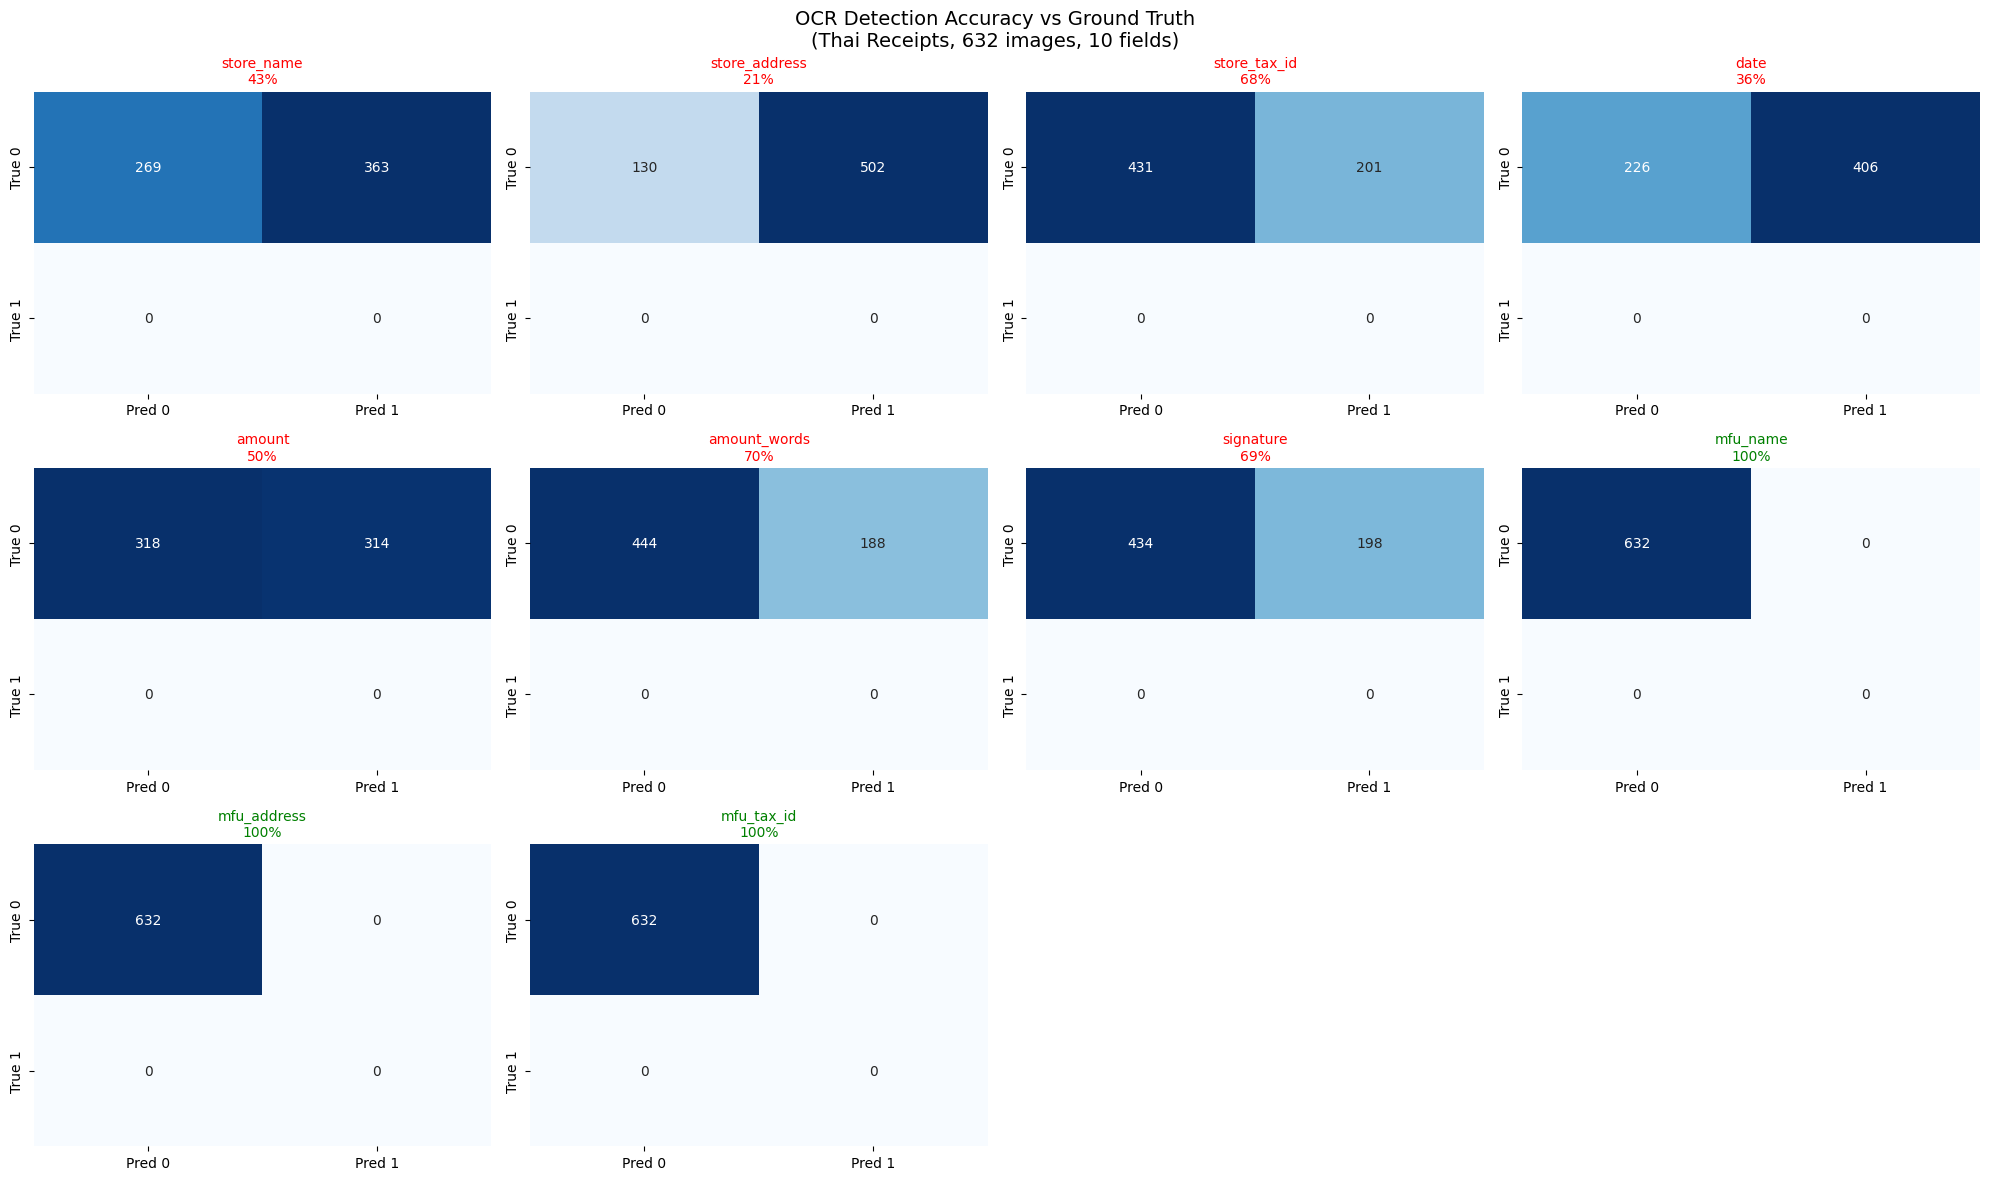

Saved --> field_accuracy_thai.png


In [12]:
print("OCR CSV columns:", ocr_df.columns.tolist())
print("Merged columns: ", merged.columns.tolist())
 
# Only use fields that exist in BOTH sides of the merge
FIELDS_OK = [f for f in FIELDS
             if f + '_gt' in merged.columns and f + '_ocr' in merged.columns]
FIELDS_MISSING = [f for f in FIELDS if f not in FIELDS_OK]
if FIELDS_MISSING:
    print(f"\n⚠ Skipping missing fields: {FIELDS_MISSING}")
print(f"✓ Using {len(FIELDS_OK)} fields: {FIELDS_OK}\n")
 
# ── Step 2: recompute accuracies for available fields only ────────────
field_accuracies = {}
for field in FIELDS_OK:
    field_accuracies[field] = accuracy_score(
        merged[field + '_gt'], merged[field + '_ocr']
    )
 
# ── Step 3: confusion matrices ────────────────────────────────────────
n = len(FIELDS_OK)
cols_plot = 4
rows_plot = (n + cols_plot - 1) // cols_plot
 
fig, axes = plt.subplots(rows_plot, cols_plot,
                         figsize=(5 * cols_plot, 4 * rows_plot))
axes = axes.flatten()
 
for idx, field in enumerate(FIELDS_OK):
    cm = confusion_matrix(
        merged[field + '_gt'], merged[field + '_ocr'], labels=[0, 1]
    )
    acc = field_accuracies[field]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                ax=axes[idx], cbar=False)
    short = field.replace('has_', '')
    axes[idx].set_title(f'{short}\n{acc*100:.0f}%',
                        color='green' if acc >= 0.8 else 'red',
                        fontsize=10)
 
for i in range(n, len(axes)):
    axes[i].set_visible(False)
 
plt.suptitle(
    f'OCR Detection Accuracy vs Ground Truth\n'
    f'(Thai Receipts, {len(merged)} images, {n} fields)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('field_accuracy_thai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved --> field_accuracy_thai.png')

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
 
# ── Use only fields that actually exist in ocr_df ────────────────────
FIELDS_OK = [f for f in FIELDS if f in ocr_df.columns]
FIELDS_MISSING = [f for f in FIELDS if f not in ocr_df.columns]
if FIELDS_MISSING:
    print(f"⚠ Fields missing from ocr_results_thai.csv (excluded from training): {FIELDS_MISSING}")
    print(f"  → To fix permanently: delete ocr_results_thai.csv and re-run build_dataset()\n")
 
X = ocr_df[FIELDS_OK]
y = ocr_df['label']
 
print(f'Dataset : {len(X)} samples | Fields used: {len(FIELDS_OK)} | Labels: {dict(y.value_counts())}')
 
# ── Guard: can't stratify if only one class exists ───────────────────
n_classes = y.nunique()
if n_classes < 2:
    print("\n⚠ WARNING: Only one class in labels — all values are the same.")
    print("  The model will trivially predict that one class and metrics are meaningless.")
    print("  Fix ground_truth_thai.csv so it has both 0s and 1s before training.\n")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if n_classes >= 2 else None
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}\n')
 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Linear SVM':          SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}
 
print(f'--- Thai Receipt Classification ({len(FIELDS_OK)} fields, class_weight=balanced) ---')
print('=' * 75)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('=' * 75)
 
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    results[name] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
                     'y_pred': y_pred, 'model': model}
    print(f"{name:<25} {acc*100:>9.1f}% {prec*100:>9.1f}% {rec*100:>9.1f}% {f1*100:>9.1f}%")
 
print('=' * 75)
best_name = max(results, key=lambda n: results[n]['f1'])
print(f'\nBest model: {best_name} (F1={results[best_name]["f1"]*100:.1f}%)')
print()
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Incomplete (0)', 'Complete (1)'],
                             zero_division=0))

Dataset : 632 samples | Fields used: 10 | Labels: {1: np.int64(400), 0: np.int64(232)}
Train: 505 | Test: 127

--- Thai Receipt Classification (10 fields, class_weight=balanced) ---
Model                       Accuracy  Precision     Recall         F1
Logistic Regression            55.9%      65.8%      62.5%      64.1%
Decision Tree                  66.1%      76.1%      67.5%      71.5%
Linear SVM                     58.3%      66.3%      68.8%      67.5%
Random Forest                  66.1%      76.1%      67.5%      71.5%
Gradient Boosting              71.7%      71.2%      92.5%      80.4%

Best model: Gradient Boosting (F1=80.4%)

                precision    recall  f1-score   support

Incomplete (0)       0.74      0.36      0.49        47
  Complete (1)       0.71      0.93      0.80        80

      accuracy                           0.72       127
     macro avg       0.73      0.64      0.65       127
  weighted avg       0.72      0.72      0.69       127



c:\Users\Computer\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
13 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
13 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Computer\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Computer\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Com

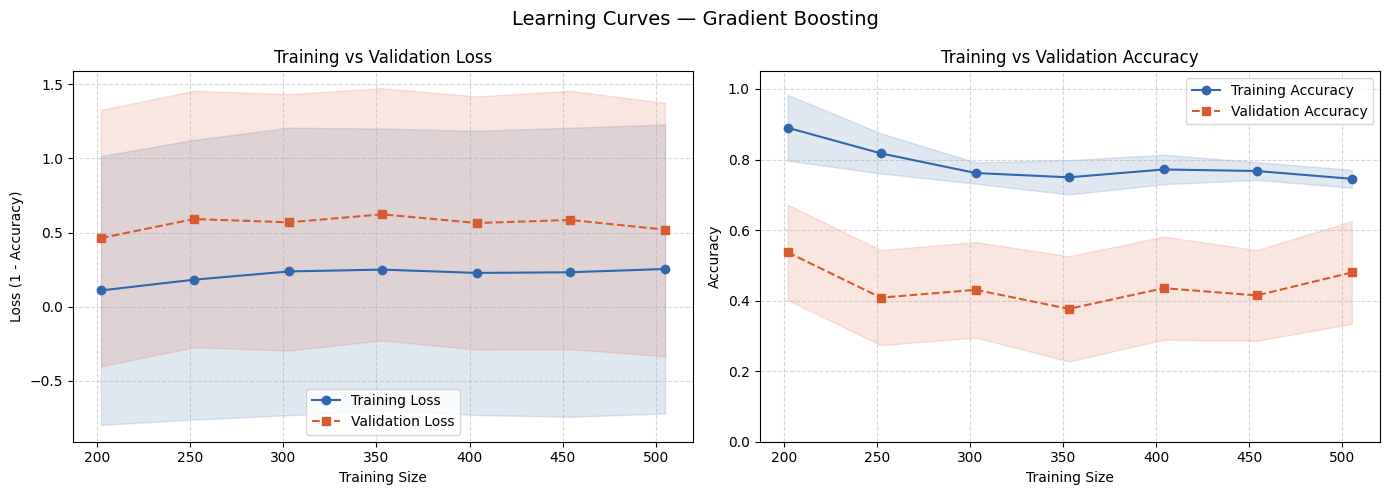

Saved: learning_curves_thai.png


In [16]:
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

# ── Training vs Validation Loss & Accuracy (using Logistic Regression as example) ──
# Replace `best_model` and `X`, `y` with your actual model and data

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve

def plot_learning_curves(model, X, y, model_name='Model'):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_acc_mean = train_scores.mean(axis=1)
    train_acc_std  = train_scores.std(axis=1)
    val_acc_mean   = val_scores.mean(axis=1)
    val_acc_std    = val_scores.std(axis=1)

    # Loss = 1 - Accuracy
    train_loss_mean = 1 - train_acc_mean
    val_loss_mean   = 1 - val_acc_mean

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning Curves — {model_name}', fontsize=14)

    # ── Loss Chart ──────────────────────────────────────────────
    axes[0].plot(train_sizes, train_loss_mean, 'o-', color='#3266ad', label='Training Loss')
    axes[0].fill_between(train_sizes,
                         train_loss_mean - (1 - train_acc_std),
                         train_loss_mean + (1 - train_acc_std),
                         alpha=0.15, color='#3266ad')
    axes[0].plot(train_sizes, val_loss_mean, 's--', color='#d85a30', label='Validation Loss')
    axes[0].fill_between(train_sizes,
                         val_loss_mean - (1 - val_acc_std),
                         val_loss_mean + (1 - val_acc_std),
                         alpha=0.15, color='#d85a30')
    axes[0].set_title('Training vs Validation Loss')
    axes[0].set_xlabel('Training Size')
    axes[0].set_ylabel('Loss (1 - Accuracy)')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # ── Accuracy Chart ──────────────────────────────────────────
    axes[1].plot(train_sizes, train_acc_mean, 'o-', color='#3266ad', label='Training Accuracy')
    axes[1].fill_between(train_sizes,
                         train_acc_mean - train_acc_std,
                         train_acc_mean + train_acc_std,
                         alpha=0.15, color='#3266ad')
    axes[1].plot(train_sizes, val_acc_mean, 's--', color='#d85a30', label='Validation Accuracy')
    axes[1].fill_between(train_sizes,
                         val_acc_mean - val_acc_std,
                         val_acc_mean + val_acc_std,
                         alpha=0.15, color='#d85a30')
    axes[1].set_title('Training vs Validation Accuracy')
    axes[1].set_xlabel('Training Size')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('learning_curves_thai.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: learning_curves_thai.png')


# ── Call it with your best model ────────────────────────────────────
# X and y must already be defined (your feature matrix and labels)
plot_learning_curves(best_model, X, y, model_name=best_name)

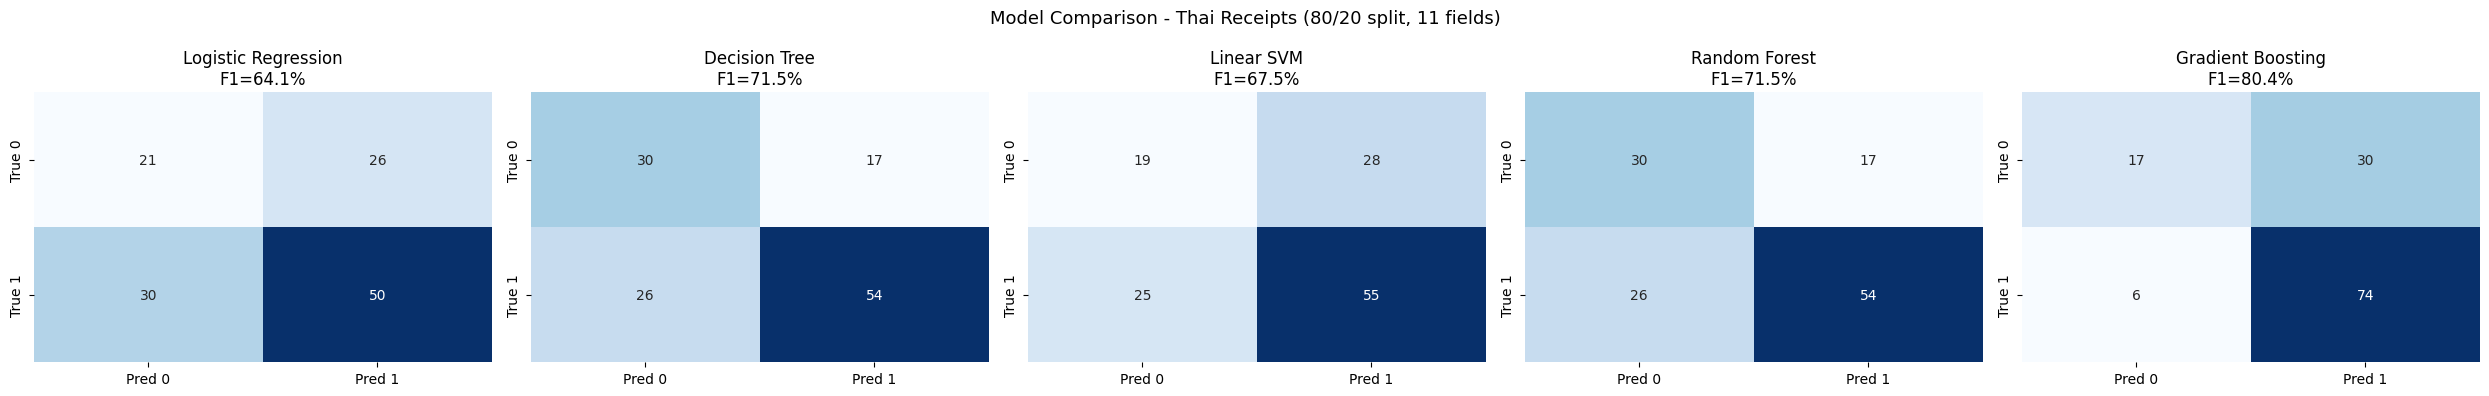

Saved --> model_comparison_thai.png


In [14]:
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nF1={res['f1']*100:.1f}%")
plt.suptitle('Model Comparison - Thai Receipts (80/20 split, 11 fields)', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_thai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved --> model_comparison_thai.png')


In [15]:
best_model = results[best_name]['model']
best_model.fit(X, y)   # retrain on ALL data
with open('best_model_thai.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f'Best model ({best_name}) saved --> best_model_thai.pkl')
print(f'Trained on all {len(X)} samples')
print()
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Incomplete (0)','Complete (1)']))


Best model (Gradient Boosting) saved --> best_model_thai.pkl
Trained on all 632 samples

                precision    recall  f1-score   support

Incomplete (0)       0.74      0.36      0.49        47
  Complete (1)       0.71      0.93      0.80        80

      accuracy                           0.72       127
     macro avg       0.73      0.64      0.65       127
  weighted avg       0.72      0.72      0.69       127

